# TP — Classification Multiclasse & Multilabel
**Module : Algorithmes de Machine Learning**

**ING1 INFO**

---

| | |
|---|---|
| **Partie I** | Classification **multiclasse** — *Heart Disease UCI* (`redwankarimsony/heart-disease-data`) |
| **Partie II** | Classification **multilabel** — Conditions cliniques multiples (dérivé du même dataset) |

**Références :**
- [Kaggle Dataset — Heart Disease Data (redwankarimsony)](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data)
- [arXiv:2412.04792 — Multi-class heart disease Detection](https://arxiv.org/html/2412.04792v1#S3)
- [sklearn.multiclass — Documentation](https://scikit-learn.org/stable/modules/multiclass.html)
- [sklearn.multioutput — Documentation](https://scikit-learn.org/stable/api/sklearn.multioutput.html)
- [MLC on Biomedical Data — GitHub](https://github.com/IoDiakou/MLC-on-biomedical-data)
- [wittgenstein (RIPPER)](https://pypi.org/project/wittgenstein/)

**Description des attributs :**

| Attribut | Description |
|---|---|
| `id` | Identifiant unique patient |
| `age` | Âge en années |
| `origin` | Lieu d'étude (Cleveland, Hungary, Switzerland, VA Long Beach) |
| `sex` | Sexe (Male / Female) |
| `cp` | Type de douleur thoracique (typical angina, atypical angina, non-anginal, asymptomatic) |
| `trestbps` | Pression artérielle au repos (mm Hg) |
| `chol` | Cholestérol sérique (mg/dl) |
| `fbs` | Glycémie à jeun > 120 mg/dl (True/False) |
| `restecg` | Résultats ECG au repos (normal, stt abnormality, lv hypertrophy) |
| `thalach` | Fréquence cardiaque maximale atteinte |
| `exang` | Angine induite par l'effort (True/False) |
| `oldpeak` | Dépression ST induite par l'effort |
| `slope` | Pente du segment ST en effort |
| `ca` | Nb de vaisseaux majeurs colorés (0–3) |
| `thal` | Thalassémie (normal, fixed defect, reversible defect) |
| `num` | **Variable cible** — sévérité (0 = sain, 1–4 = maladie croissante) |


## 0. Imports & Configuration

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Classifieurs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# sklearn.multiclass
from sklearn.multiclass import (
    OneVsRestClassifier,
    OneVsOneClassifier,
    OutputCodeClassifier
)

# sklearn.multioutput
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain

# Métriques
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    hamming_loss,
    jaccard_score,
    multilabel_confusion_matrix
)

# RIPPER — wittgenstein (pip install wittgenstein)
try:
    import wittgenstein as lw
    WITTGENSTEIN_OK = True
except ImportError:
    WITTGENSTEIN_OK = False
    print('⚠️  wittgenstein non installé — pip install wittgenstein')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
SEED = 42
print('✅ Imports OK')


✅ Imports OK


---
# PARTIE I — Classification Multiclasse
## Dataset : Heart Disease UCI (`redwankarimsony/heart-disease-data`)

Ce dataset regroupe **4 bases hospitalières** : Cleveland, Hungary, Switzerland, VA Long Beach.  
Il contient **920 enregistrements** de patients avec 15 attributs cliniques.

**Variable cible `num`** — sévérité de la maladie cardiaque :

| num | Signification |
|-----|---------------|
| 0 | Aucune maladie cardiaque |
| 1 | Maladie légère |
| 2 | Maladie modérée |
| 3 | Maladie sévère |
| 4 | Maladie très sévère |

**Stratégies `sklearn.multiclass` utilisées :**

| Classe | Nb. classifieurs | Principe |
|---|---|---|
| `OneVsRestClassifier` | N | classe k vs. toutes les autres |
| `OneVsOneClassifier` | N(N-1)/2 | une paire (i,j) par classifieur |
| `OutputCodeClassifier` | code_size × N | code binaire par classe (ECOC) |


## 1.1 Chargement via kagglehub

In [ ]:
import kagglehub

# Téléchargement automatique du dataset
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")
# print("Path to dataset files:", path)

csv_files = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)
# print('\n📄 Fichiers CSV trouvés :')
# for f in csv_files:
#     print(' -', os.path.basename(f), '|', round(os.path.getsize(f)/1024, 1), 'KB')


Path to dataset files: C:\Users\Root\.cache\kagglehub\datasets\redwankarimsony\heart-disease-data\versions\6

📄 Fichiers CSV trouvés :
 - heart_disease_uci.csv | 77.5 KB


In [44]:
# Chargement du fichier CSV principal
df_raw = pd.read_csv(csv_files[0])

print(f'Dimensions     : {df_raw.shape}')
print(f'Colonnes       : {list(df_raw.columns)}')
df_raw.head()


Dimensions     : (920, 16)
Colonnes       : ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 1.2 Exploration des Données (EDA)

In [45]:
# Informations générales
df_raw.info()
print('\n=== Statistiques descriptives ===')
df_raw.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

=== Statistiques descriptives ===


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


In [46]:
# Valeurs manquantes & types
df_raw.replace('?', np.nan, inplace=True)

missing = pd.DataFrame({
    'Type'      : df_raw.dtypes,
    'Manquant'  : df_raw.isnull().sum(),
    'Manquant%' : (df_raw.isnull().mean() * 100).round(2)
})
print(missing[missing['Manquant'] > 0].to_string())

print(f'\nColonne cible : "num"')
print('Distribution :')
print(df_raw['num'].value_counts().sort_index())


             Type  Manquant  Manquant%
trestbps  float64        59       6.41
chol      float64        30       3.26
fbs        object        90       9.78
restecg    object         2       0.22
thalch    float64        55       5.98
exang      object        55       5.98
oldpeak   float64        62       6.74
slope      object       309      33.59
ca        float64       611      66.41
thal       object       486      52.83

Colonne cible : "num"
Distribution :
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


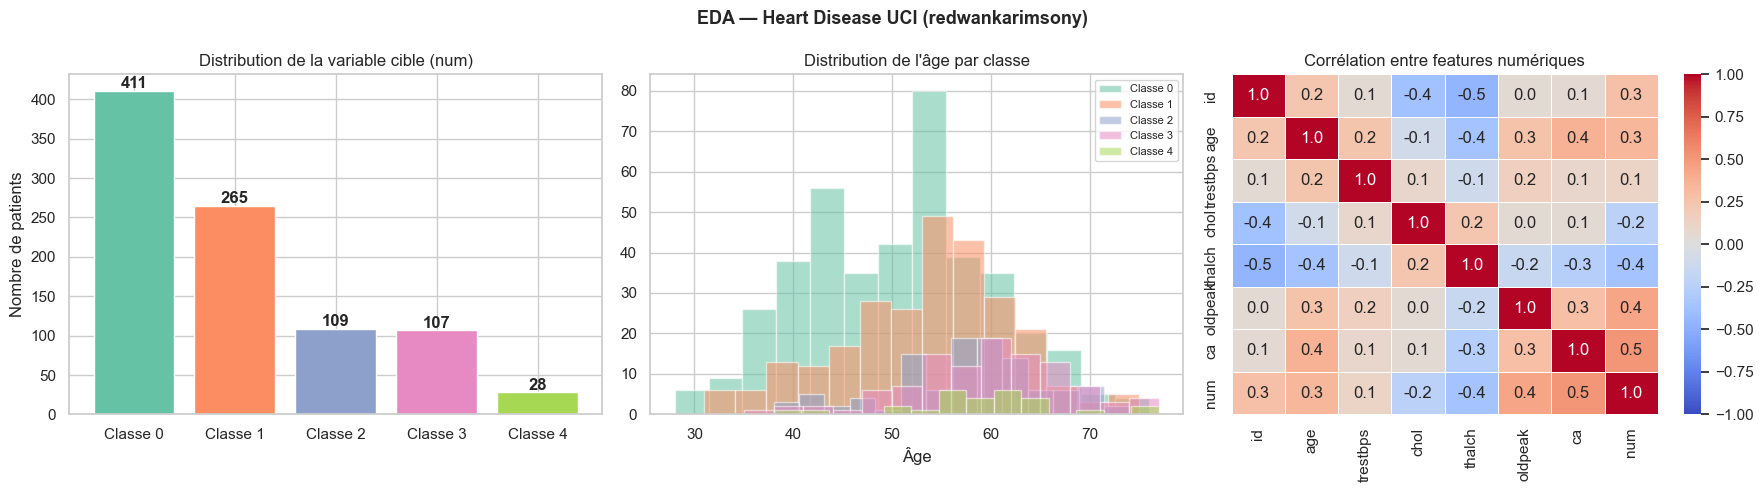

In [47]:
# ── Visualisation EDA ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution de la cible
cc = df_raw['num'].value_counts().sort_index()
axes[0].bar(
    [f'Classe {i}' for i in cc.index],
    cc.values,
    color=sns.color_palette('Set2', len(cc))
)
axes[0].set_title('Distribution de la variable cible (num)')
axes[0].set_ylabel('Nombre de patients')
for i, v in enumerate(cc.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# 2. Distribution de l'âge par classe
for cls in sorted(df_raw['num'].dropna().unique()):
    sub = df_raw[df_raw['num'] == cls]['age'].dropna()
    axes[1].hist(sub, alpha=0.55, bins=14, label=f'Classe {int(cls)}')
axes[1].set_title("Distribution de l'âge par classe")
axes[1].set_xlabel('Âge')
axes[1].legend(fontsize=8)

# 3. Heatmap corrélations numériques
num_cols = df_raw.select_dtypes(include='number').columns.tolist()
corr = df_raw[num_cols].corr()
sns.heatmap(corr, ax=axes[2], cmap='coolwarm',
            annot=(len(num_cols) <= 10), fmt='.1f',
            linewidths=0.4, vmin=-1, vmax=1)
axes[2].set_title('Corrélation entre features numériques')

plt.suptitle('EDA — Heart Disease UCI (redwankarimsony)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


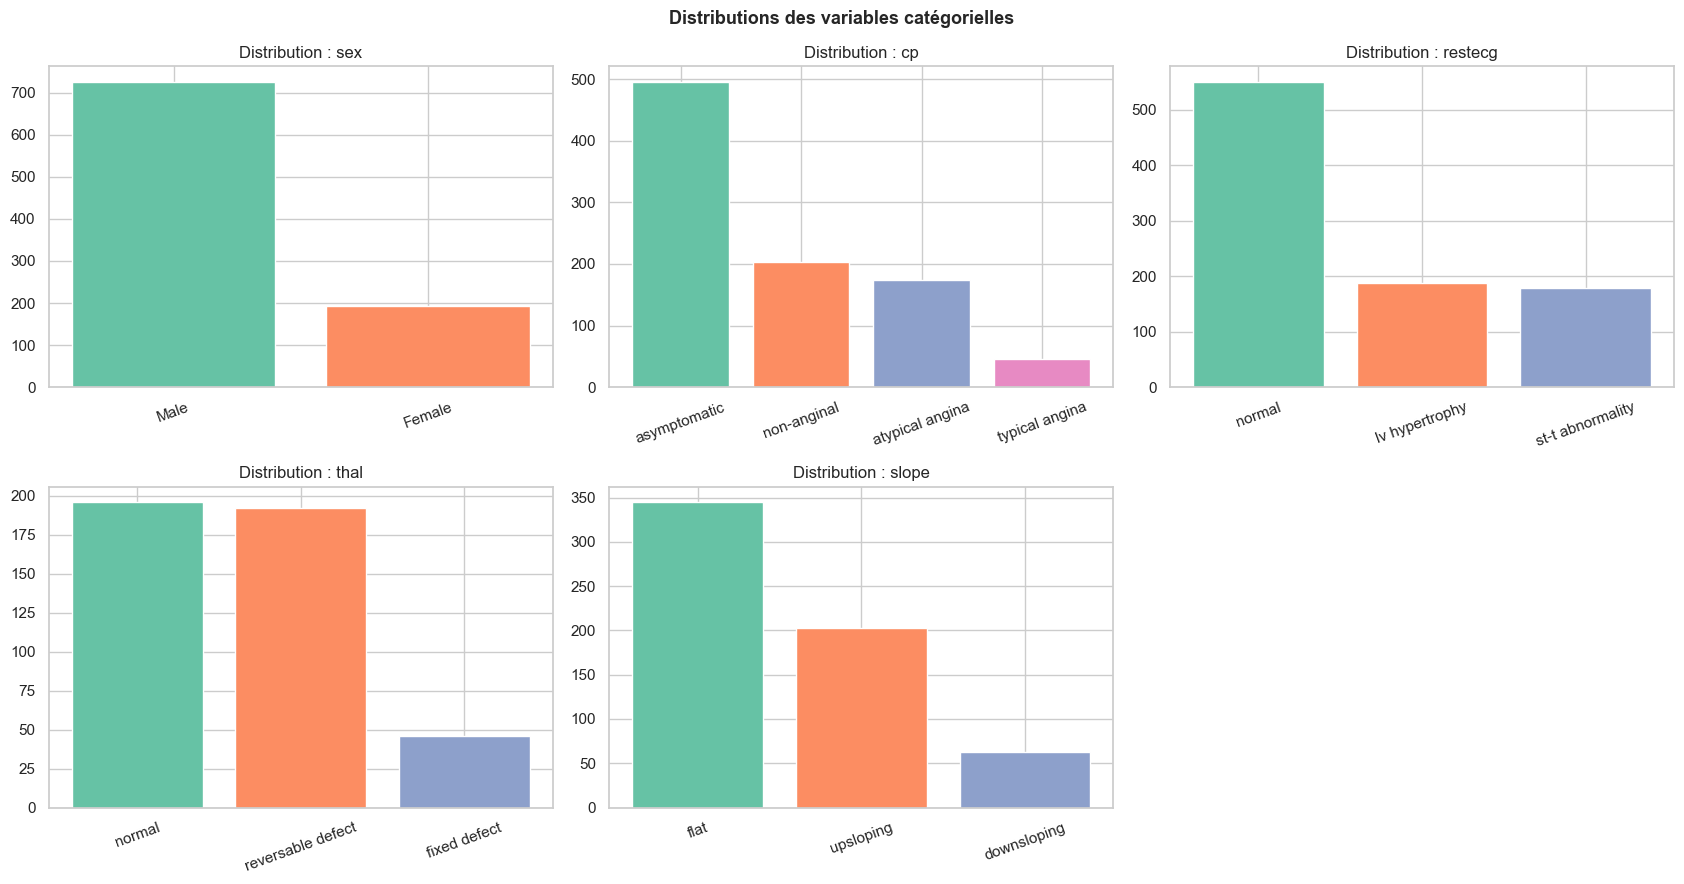

In [48]:
# Distributions des variables catégorielles
cat_cols_eda = ['sex', 'cp', 'restecg', 'thal', 'slope', 'origin']
cat_cols_eda = [c for c in cat_cols_eda if c in df_raw.columns]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.ravel()

for i, col in enumerate(cat_cols_eda):
    vc = df_raw[col].value_counts()
    axes[i].bar(vc.index.astype(str), vc.values,
                color=sns.color_palette('Set2', len(vc)))
    axes[i].set_title(f'Distribution : {col}')
    axes[i].tick_params(axis='x', rotation=20)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions des variables catégorielles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


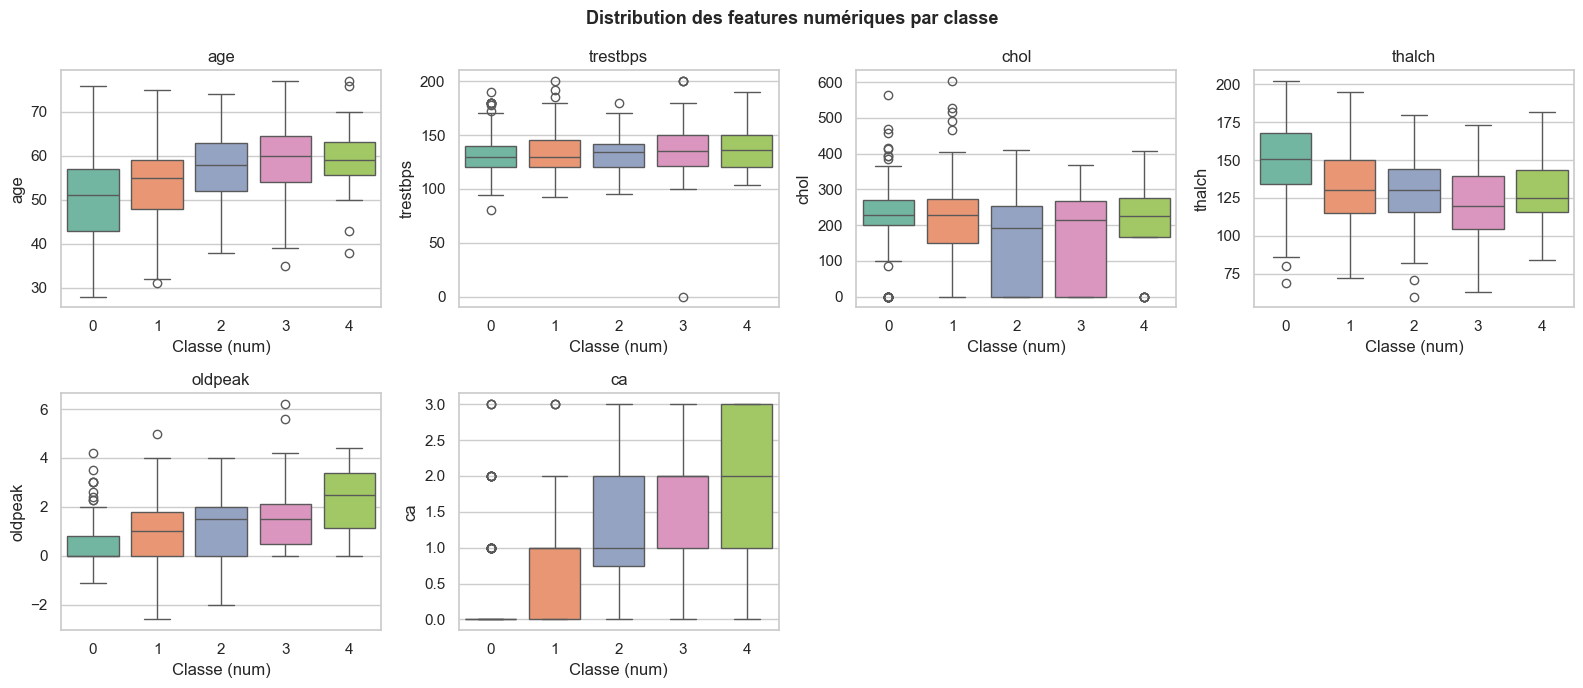

In [49]:
# Boxplots des features numériques par classe
num_feats = [c for c in df_raw.select_dtypes(include='number').columns
             if c not in ['num', 'id']]

ncols = 4
nrows = (len(num_feats) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.ravel()

for i, feat in enumerate(num_feats):
    sns.boxplot(data=df_raw, x='num', y=feat, palette='Set2', ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('Classe (num)')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des features numériques par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1.3 Prétraitement

In [50]:
df = df_raw.copy()
df.replace('?', np.nan, inplace=True)

# Supprimer colonnes non pertinentes
drop_cols = [c for c in ['id'] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

# Séparation features / cible
X = df.drop(columns=['num'])
y = df['num']

# Supprimer les lignes où y est NaN
mask = y.notna()
X, y = X[mask], y[mask]
y = y.astype(int)

# Encodage LabelEncoder pour les colonnes catégorielles
#   sex, cp, fbs, restecg, exang, slope, thal, origin
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'Colonnes catégorielles encodées : {cat_cols}')
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str)) # type: ignore

X = X.astype(float)

# Imputation des valeurs manquantes (médiane)
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)
X = pd.DataFrame(X_imp, columns=X.columns)

print(f'\nShape features : {X.shape}')
print(f'Classes        : {sorted(y.unique())}')
print(f'Valeurs manquantes restantes : {X.isnull().sum().sum()}')
print('\nDistribution des classes :')
print(y.value_counts().sort_index())


Colonnes catégorielles encodées : ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

Shape features : (920, 14)
Classes        : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Valeurs manquantes restantes : 0

Distribution des classes :
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [51]:
# Train / Test split (80 / 20) stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Normalisation StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {X_train_sc.shape}  |  Test : {X_test_sc.shape}')
print('Distribution classes (train) :')
print(y_train.value_counts().sort_index())


Train : (736, 14)  |  Test : (184, 14)
Distribution classes (train) :
num
0    329
1    212
2     87
3     86
4     22
Name: count, dtype: int64


## 1.4 Algorithmes de Classification Multiclasse

### Algorithmes requis
- **KNN** (K-Nearest Neighbors)
- **Decision Tree**
- **Ensemble Learning** (Random Forest, AdaBoost, Bagging, Gradient Boosting)
- **RIPPER** (Rule-based — via `wittgenstein`)

### Stratégies `sklearn.multiclass`
- **OneVsRest (OvR)**, **OneVsOne (OvO)**, **OutputCodeClassifier (ECOC)**


### 1.4.1 K-Nearest Neighbors (KNN)

- Algorithme **non-paramétrique** basé sur la distance
- Classe prédite = classe majoritaire parmi les **k voisins les plus proches**
- Nativement multiclasse
- Sensible à l'échelle → **normalisation indispensable**


In [52]:
# KNN — recherche du meilleur k par cross-validation
from sklearn.model_selection import cross_val_score

k_values = [3, 5, 7, 9, 11]
cv_k = {}
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='accuracy')
    cv_k[k] = scores.mean()
    print(f'  k={k:>2} → Accuracy CV = {scores.mean():.4f} ± {scores.std():.4f}')

best_k = max(cv_k, key=cv_k.get) # type: ignore
print(f'\n✅ Meilleur k = {best_k} (Accuracy CV = {cv_k[best_k]:.4f})')

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_sc, y_train)
y_pred_knn = knn_best.predict(X_test_sc)

print('\n' + '=' * 60)
print(f'  KNN (k={best_k})')
print('=' * 60)
print(f'  Accuracy         : {accuracy_score(y_test, y_pred_knn):.4f}')
print(f'  F1-Score (macro) : {f1_score(y_test, y_pred_knn, average="macro", zero_division=0):.4f}')
print()
print(classification_report(y_test, y_pred_knn, zero_division=0))


  k= 3 → Accuracy CV = 0.5530 ± 0.0135
  k= 5 → Accuracy CV = 0.5666 ± 0.0226
  k= 7 → Accuracy CV = 0.5585 ± 0.0131
  k= 9 → Accuracy CV = 0.5775 ± 0.0181
  k=11 → Accuracy CV = 0.5775 ± 0.0093

✅ Meilleur k = 9 (Accuracy CV = 0.5775)

  KNN (k=9)
  Accuracy         : 0.6033
  F1-Score (macro) : 0.3375

              precision    recall  f1-score   support

           0       0.74      0.88      0.80        82
           1       0.55      0.64      0.59        53
           2       0.18      0.14      0.15        22
           3       0.25      0.10      0.14        21
           4       0.00      0.00      0.00         6

    accuracy                           0.60       184
   macro avg       0.34      0.35      0.34       184
weighted avg       0.54      0.60      0.56       184



### 1.4.2 Decision Tree (Arbre de Décision)

- Partitionne l'espace de features par des seuils successifs
- Nativement multiclasse
- Interprétable mais prone à l'overfitting → contrôlé par `max_depth`


In [53]:
# Decision Tree — tuning max_depth
depth_values = [3, 4, 5, 6, 8, None]
cv_dt = {}
for d in depth_values:
    dt = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    scores = cross_val_score(dt, X_train_sc, y_train, cv=5, scoring='accuracy')
    cv_dt[d] = scores.mean()
    label = str(d) if d is not None else 'None'
    print(f'  max_depth={label:>4} → Accuracy CV = {scores.mean():.4f} ± {scores.std():.4f}')

best_depth = max(cv_dt, key=cv_dt.get) # type: ignore
print(f'\n✅ Meilleur max_depth = {best_depth}')

dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=SEED)
dt_best.fit(X_train_sc, y_train)
y_pred_dt = dt_best.predict(X_test_sc)

print('\n' + '=' * 60)
print(f'  Decision Tree (max_depth={best_depth})')
print('=' * 60)
print(f'  Accuracy         : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'  F1-Score (macro) : {f1_score(y_test, y_pred_dt, average="macro", zero_division=0):.4f}')
print()
print(classification_report(y_test, y_pred_dt, zero_division=0))


  max_depth=   3 → Accuracy CV = 0.5014 ± 0.0157
  max_depth=   4 → Accuracy CV = 0.5245 ± 0.0224
  max_depth=   5 → Accuracy CV = 0.5462 ± 0.0280
  max_depth=   6 → Accuracy CV = 0.5217 ± 0.0217
  max_depth=   8 → Accuracy CV = 0.5245 ± 0.0294
  max_depth=None → Accuracy CV = 0.4959 ± 0.0215

✅ Meilleur max_depth = 5

  Decision Tree (max_depth=5)
  Accuracy         : 0.5924
  F1-Score (macro) : 0.3898

              precision    recall  f1-score   support

           0       0.80      0.84      0.82        82
           1       0.46      0.62      0.53        53
           2       0.24      0.23      0.23        22
           3       0.20      0.05      0.08        21
           4       1.00      0.17      0.29         6

    accuracy                           0.59       184
   macro avg       0.54      0.38      0.39       184
weighted avg       0.58      0.59      0.57       184



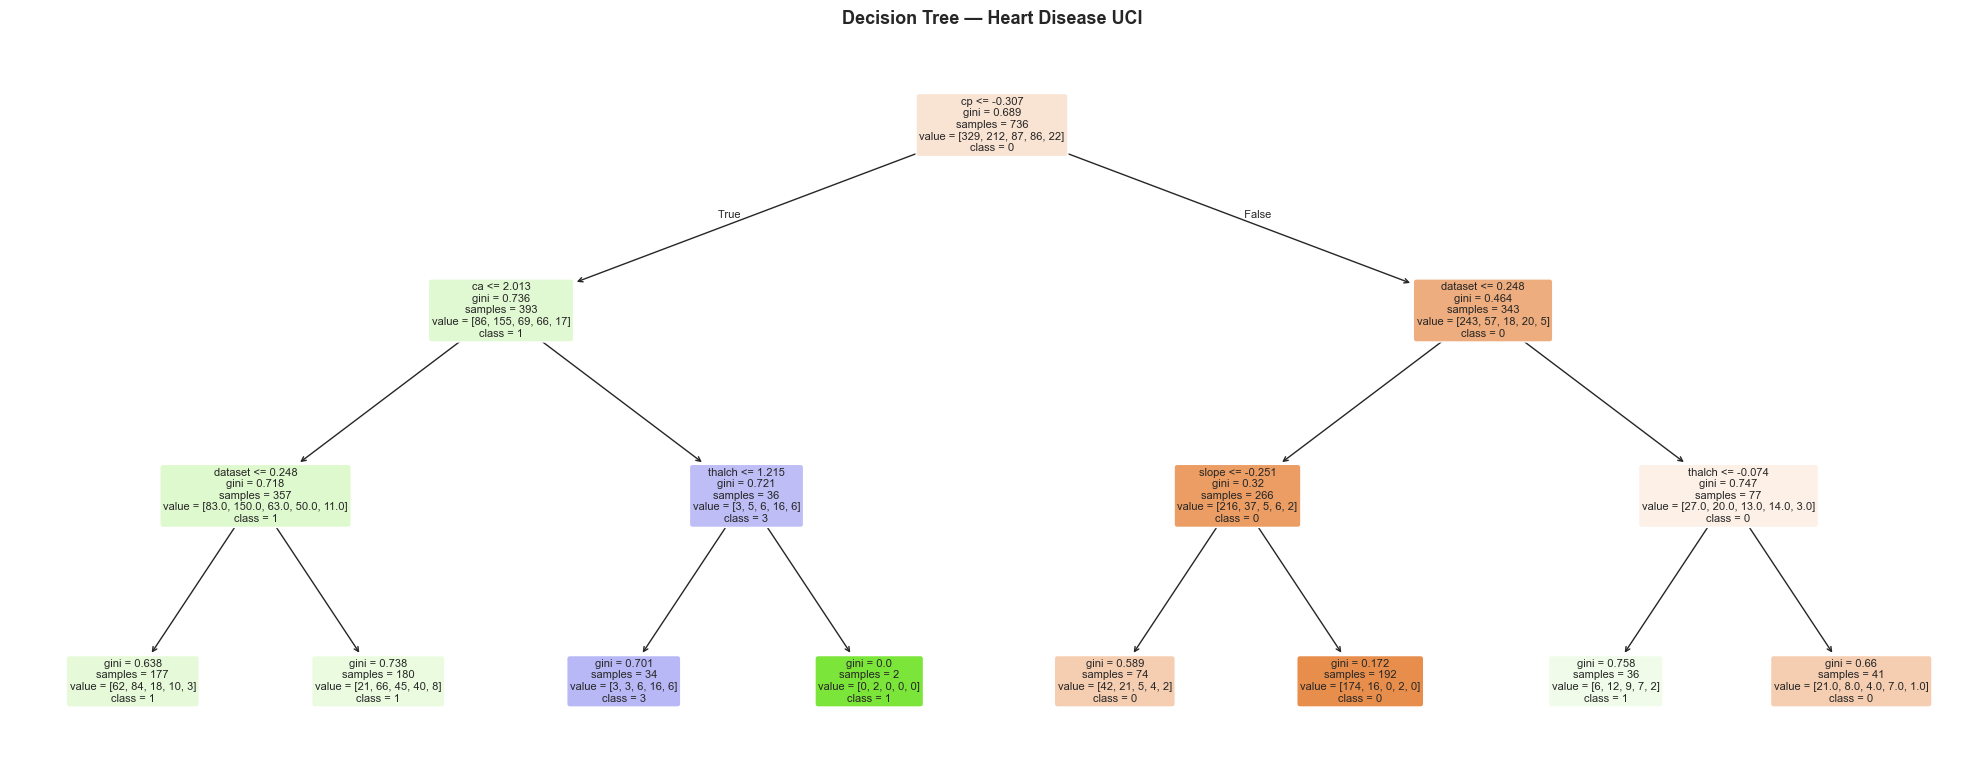

In [54]:
# Visualisation de l'arbre (profondeur limitée à 3 pour lisibilité)
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_best if best_depth is not None and best_depth <= 4
    else DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X_train_sc, y_train),
    feature_names=X.columns.tolist(),
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True, rounded=True, fontsize=8, ax=ax
)
ax.set_title('Decision Tree — Heart Disease UCI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.4.3 Ensemble Learning

L'ensemble learning combine plusieurs modèles pour réduire la variance et le biais.  
Trois familles sont utilisées ici :

| Méthode | Principe | Algorithme |
|---|---|---|
| **Bagging** | Moyennage de modèles parallèles (bootstrap) | `BaggingClassifier`, `RandomForestClassifier` |
| **Boosting** | Modèles séquentiels, correction d'erreurs | `AdaBoostClassifier`, `GradientBoostingClassifier` |
| **Random Forest** | Bagging + sélection aléatoire de features | `RandomForestClassifier` |

Référence :  
- [sklearn — Plot Forest Iris](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_iris.html)  
- [sklearn — AdaBoost Multiclass](https://scikit-learn.org/stable/auto_examples/ensemble/plot_adaboost_multiclass.html)  
- [sklearn — OOB Error Estimation](https://scikit-learn.org/stable/auto_examples/ensemble/plot_ensemble_oob.html)


In [55]:
# ── Random Forest ────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

print('=' * 60)
print('  Random Forest (n_estimators=200)')
print('=' * 60)
print(f'  Accuracy         : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  F1-Score (macro) : {f1_score(y_test, y_pred_rf, average="macro", zero_division=0):.4f}')
print(f'  OOB Score        : {RandomForestClassifier(n_estimators=200, oob_score=True, random_state=SEED).fit(X_train_sc, y_train).oob_score_:.4f}')
print()
print(classification_report(y_test, y_pred_rf, zero_division=0))


  Random Forest (n_estimators=200)
  Accuracy         : 0.6033
  F1-Score (macro) : 0.3455
  OOB Score        : 0.5611

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        82
           1       0.54      0.62      0.58        53
           2       0.21      0.18      0.20        22
           3       0.13      0.10      0.11        21
           4       0.00      0.00      0.00         6

    accuracy                           0.60       184
   macro avg       0.34      0.36      0.35       184
weighted avg       0.56      0.60      0.58       184



In [56]:
# ── AdaBoost Multiclass ──────────────────────────────────────────
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=200,
    learning_rate=0.5,
    random_state=SEED
)
ada.fit(X_train_sc, y_train)
y_pred_ada = ada.predict(X_test_sc)

print('=' * 60)
print('  AdaBoost (SAMME — Decision Stump, n=200)')
print('=' * 60)
print(f'  Accuracy         : {accuracy_score(y_test, y_pred_ada):.4f}')
print(f'  F1-Score (macro) : {f1_score(y_test, y_pred_ada, average="macro", zero_division=0):.4f}')
print()
print(classification_report(y_test, y_pred_ada, zero_division=0))


  AdaBoost (SAMME — Decision Stump, n=200)
  Accuracy         : 0.5815
  F1-Score (macro) : 0.3581

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        82
           1       0.53      0.57      0.55        53
           2       0.26      0.23      0.24        22
           3       0.17      0.19      0.18        21
           4       0.00      0.00      0.00         6

    accuracy                           0.58       184
   macro avg       0.35      0.36      0.36       184
weighted avg       0.56      0.58      0.57       184



In [57]:
# ── Gradient Boosting ────────────────────────────────────────────
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                 max_depth=4, random_state=SEED)
gb.fit(X_train_sc, y_train)
y_pred_gb = gb.predict(X_test_sc)

print('=' * 60)
print('  Gradient Boosting (n=150, lr=0.1)')
print('=' * 60)
print(f'  Accuracy         : {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'  F1-Score (macro) : {f1_score(y_test, y_pred_gb, average="macro", zero_division=0):.4f}')
print()
print(classification_report(y_test, y_pred_gb, zero_division=0))


  Gradient Boosting (n=150, lr=0.1)
  Accuracy         : 0.6196
  F1-Score (macro) : 0.4223

              precision    recall  f1-score   support

           0       0.76      0.83      0.80        82
           1       0.58      0.60      0.59        53
           2       0.42      0.36      0.39        22
           3       0.40      0.29      0.33        21
           4       0.00      0.00      0.00         6

    accuracy                           0.62       184
   macro avg       0.43      0.42      0.42       184
weighted avg       0.60      0.62      0.61       184



In [58]:
# ── Bagging ──────────────────────────────────────────────────────
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=6),
    n_estimators=100,
    max_samples=0.8,
    max_features=0.8,
    random_state=SEED,
    n_jobs=-1
)
bag.fit(X_train_sc, y_train)
y_pred_bag = bag.predict(X_test_sc)

print('=' * 60)
print('  Bagging (Decision Tree, n=100)')
print('=' * 60)
print(f'  Accuracy         : {accuracy_score(y_test, y_pred_bag):.4f}')
print(f'  F1-Score (macro) : {f1_score(y_test, y_pred_bag, average="macro", zero_division=0):.4f}')
print()
print(classification_report(y_test, y_pred_bag, zero_division=0))


  Bagging (Decision Tree, n=100)
  Accuracy         : 0.6033
  F1-Score (macro) : 0.3548

              precision    recall  f1-score   support

           0       0.80      0.87      0.83        82
           1       0.49      0.62      0.55        53
           2       0.23      0.14      0.17        22
           3       0.27      0.19      0.22        21
           4       0.00      0.00      0.00         6

    accuracy                           0.60       184
   macro avg       0.36      0.36      0.35       184
weighted avg       0.56      0.60      0.57       184



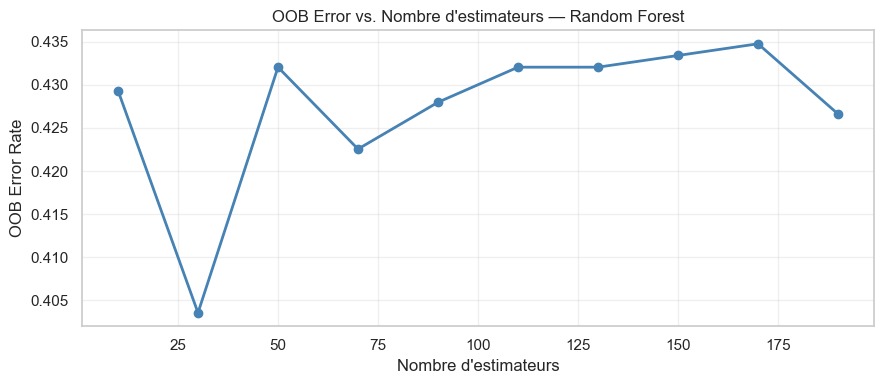

In [59]:
# OOB Error en fonction du nombre d'estimateurs (Random Forest)
# Référence : https://scikit-learn.org/stable/auto_examples/ensemble/plot_ensemble_oob.html

oob_errors = {}
n_estimators_range = range(10, 210, 20)

for n_est in n_estimators_range:
    rf_oob = RandomForestClassifier(
        n_estimators=n_est, oob_score=True, random_state=SEED, n_jobs=-1
    )
    rf_oob.fit(X_train_sc, y_train)
    oob_errors[n_est] = 1 - rf_oob.oob_score_

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(oob_errors.keys()), list(oob_errors.values()),
        marker='o', color='steelblue', linewidth=2)
ax.set_xlabel("Nombre d'estimateurs")
ax.set_ylabel("OOB Error Rate")
ax.set_title("OOB Error vs. Nombre d'estimateurs — Random Forest")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 1.4.4 Stratégies sklearn.multiclass

#### OneVsRest (OvR)
- **N classifieurs binaires** — un par classe  
- Prédiction = argmax des probabilités  
- Ref : [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html)

#### OneVsOne (OvO)
- **N(N-1)/2 classifieurs binaires** — un par paire de classes  
- Prédiction = vote majoritaire  
- Plus robuste au déséquilibre de classes

#### OutputCodeClassifier (ECOC)
- Chaque classe → code binaire de longueur `code_size × N`  
- Prédiction = classe dont le code est le plus proche (distance de Hamming)  
- Correction d'erreurs intégrée


In [60]:
# ── OneVsRest — KNN ──────────────────────────────────────────────
ovr_knn = OneVsRestClassifier(
    KNeighborsClassifier(n_neighbors=best_k),
    n_jobs=-1
)
ovr_knn.fit(X_train_sc, y_train)
y_pred_ovr = ovr_knn.predict(X_test_sc)

n_cls = len(np.unique(y_train))
print('=' * 60)
print('  OneVsRest — KNN')
print('=' * 60)
print(f'  Accuracy          : {accuracy_score(y_test, y_pred_ovr):.4f}')
print(f'  F1-Score (macro)  : {f1_score(y_test, y_pred_ovr, average="macro", zero_division=0):.4f}')
print(f'  Nb classifieurs   : {len(ovr_knn.estimators_)} (= N classes)')
print()
print(classification_report(y_test, y_pred_ovr, zero_division=0))


  OneVsRest — KNN
  Accuracy          : 0.6033
  F1-Score (macro)  : 0.3375
  Nb classifieurs   : 5 (= N classes)

              precision    recall  f1-score   support

           0       0.74      0.88      0.80        82
           1       0.55      0.64      0.59        53
           2       0.18      0.14      0.15        22
           3       0.25      0.10      0.14        21
           4       0.00      0.00      0.00         6

    accuracy                           0.60       184
   macro avg       0.34      0.35      0.34       184
weighted avg       0.54      0.60      0.56       184



In [61]:
# ── OneVsOne — Decision Tree ─────────────────────────────────────
ovo_dt = OneVsOneClassifier(
    DecisionTreeClassifier(max_depth=best_depth, random_state=SEED)
)
ovo_dt.fit(X_train_sc, y_train)
y_pred_ovo = ovo_dt.predict(X_test_sc)

n_pairs = n_cls * (n_cls - 1) // 2
print('=' * 60)
print('  OneVsOne — Decision Tree')
print('=' * 60)
print(f'  Accuracy          : {accuracy_score(y_test, y_pred_ovo):.4f}')
print(f'  F1-Score (macro)  : {f1_score(y_test, y_pred_ovo, average="macro", zero_division=0):.4f}')
print(f'  Nb classifieurs   : {n_pairs} = {n_cls}×({n_cls}-1)/2')
print()
print(classification_report(y_test, y_pred_ovo, zero_division=0))


  OneVsOne — Decision Tree
  Accuracy          : 0.5924
  F1-Score (macro)  : 0.4276
  Nb classifieurs   : 10 = 5×(5-1)/2

              precision    recall  f1-score   support

           0       0.77      0.83      0.80        82
           1       0.58      0.55      0.56        53
           2       0.27      0.18      0.22        22
           3       0.26      0.29      0.27        21
           4       0.25      0.33      0.29         6

    accuracy                           0.59       184
   macro avg       0.43      0.44      0.43       184
weighted avg       0.58      0.59      0.59       184



In [62]:
# ── OutputCodeClassifier (ECOC) — Random Forest ──────────────────
ecoc = OutputCodeClassifier(
    RandomForestClassifier(n_estimators=100, random_state=SEED),
    code_size=2.0,
    random_state=SEED
)
ecoc.fit(X_train_sc, y_train)
y_pred_ecoc = ecoc.predict(X_test_sc)

print('=' * 60)
print('  OutputCodeClassifier (ECOC) — Random Forest')
print('=' * 60)
print(f'  Accuracy          : {accuracy_score(y_test, y_pred_ecoc):.4f}')
print(f'  F1-Score (macro)  : {f1_score(y_test, y_pred_ecoc, average="macro", zero_division=0):.4f}')
print(f'  Nb classifieurs   : {len(ecoc.estimators_)}')
print(f'  Longueur du code  : {int(2.0 * n_cls)} bits = 2.0 × {n_cls} classes')
print()
print(classification_report(y_test, y_pred_ecoc, zero_division=0))


  OutputCodeClassifier (ECOC) — Random Forest
  Accuracy          : 0.5924
  F1-Score (macro)  : 0.3599
  Nb classifieurs   : 10
  Longueur du code  : 10 bits = 2.0 × 5 classes

              precision    recall  f1-score   support

           0       0.81      0.87      0.84        82
           1       0.61      0.53      0.57        53
           2       0.26      0.41      0.32        22
           3       0.20      0.05      0.08        21
           4       0.00      0.00      0.00         6

    accuracy                           0.59       184
   macro avg       0.38      0.37      0.36       184
weighted avg       0.59      0.59      0.58       184



### 1.4.5 RIPPER — Classification Basée sur des Règles

**RIPPER** (*Repeated Incremental Pruning to Produce Error Reduction*) est un algorithme de classification par **règles SI-ALORS**.  
Il n'est **pas disponible dans scikit-learn** → on utilise la librairie [`wittgenstein`](https://pypi.org/project/wittgenstein/).

**Principe :**
- Génère un ensemble de règles interprétables couvrant les exemples positifs
- Élagage (*pruning*) pour contrôler l'overfitting
- Très lisible : chaque classe correspond à un ruleset explicite

**Adaptation multiclasse :**  
RIPPER est binaire par nature → approche **One-vs-Rest manuelle** :  
pour chaque classe k, un RIPPER binaire est entraîné (classe k vs toutes les autres).

```bash
pip install wittgenstein
```


In [63]:
# Installation wittgenstein si nécessaire
if not WITTGENSTEIN_OK:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wittgenstein', '-q'])
    import wittgenstein as lw
    WITTGENSTEIN_OK = True

import wittgenstein as lw

feature_names = list(X.columns)
X_train_df = pd.DataFrame(X_train_sc, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_sc,  columns=feature_names)

classes = sorted(y_train.unique())
print(f'Classes : {classes}')
print('Entraînement RIPPER (One-vs-Rest)...\n')

ripper_classifiers = {}
ripper_scores = np.zeros((len(X_test_df), len(classes)))

for i, cls in enumerate(classes):
    y_bin_train = (y_train == cls).astype(int).reset_index(drop=True)
    train_df = X_train_df.copy()
    train_df['__target__'] = y_bin_train

    ripper = lw.RIPPER(random_state=SEED)
    ripper.fit(train_df, class_feat='__target__', pos_class=1)
    ripper_classifiers[cls] = ripper

    preds_bin = np.array(ripper.predict(X_test_df)).astype(int)
    ripper_scores[:, i] = preds_bin
    print(f'  Classe {cls} : {len(ripper.ruleset_)} règle(s) apprise(s)')

# Résolution des conflits (argmax ou classe par défaut)
majority_class = int(y_train.value_counts().idxmax())
y_pred_ripper = []

for row in ripper_scores:
    positives = np.where(row == 1)[0]
    if len(positives) >= 1:
        y_pred_ripper.append(classes[positives[0]])
    else:
        y_pred_ripper.append(majority_class)

y_pred_ripper = np.array(y_pred_ripper)

print('\n' + '=' * 60)
print('  RIPPER — Rule-based (wittgenstein) — One-vs-Rest')
print('=' * 60)
print(f'  Accuracy         : {accuracy_score(y_test, y_pred_ripper):.4f}')
print(f'  F1-Score (macro) : {f1_score(y_test, y_pred_ripper, average="macro", zero_division=0):.4f}')
print()
print(classification_report(y_test, y_pred_ripper, zero_division=0))


Classes : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Entraînement RIPPER (One-vs-Rest)...

  Classe 0 : 10 règle(s) apprise(s)
  Classe 1 : 4 règle(s) apprise(s)
  Classe 2 : 3 règle(s) apprise(s)
  Classe 3 : 6 règle(s) apprise(s)
  Classe 4 : 4 règle(s) apprise(s)

  RIPPER — Rule-based (wittgenstein) — One-vs-Rest
  Accuracy         : 0.5435
  F1-Score (macro) : 0.3531

              precision    recall  f1-score   support

           0       0.54      0.94      0.68        82
           1       0.73      0.30      0.43        53
           2       0.33      0.05      0.08        22
           3       0.44      0.19      0.27        21
           4       0.29      0.33      0.31         6

    accuracy                           0.54       184
   macro avg       0.47      0.36      0.35       184
weighted avg       0.55      0.54      0.48       184



In [64]:
# Affichage des règles SI-ALORS apprises par RIPPER
print('=== Règles RIPPER par classe ===\n')
for cls, ripper in ripper_classifiers.items():
    n_rules = len(ripper.ruleset_)
    print(f'--- Classe {cls} ({n_rules} règle(s)) ---')
    print(ripper.ruleset_)
    print()


=== Règles RIPPER par classe ===

--- Classe 0 (10 règle(s)) ---
[[exang=-0.7821844973961652^dataset=-0.1927670993829184^cp=0.21344062094717678] V [exang=-0.7821844973961652^thal=0.44997477459261226^thalch=>1.28] V [exang=-0.7821844973961652^cp=1.2537869588089126^oldpeak=<-0.8^thal=-0.6842082189010951^age=<-1.41] V [exang=-0.7821844973961652^cp=1.2537869588089126^ca=-0.36137138849999445^thalch=0.88-1.28] V [sex=-1.882341594010824^slope=1.4261510675293585] V [exang=-0.7821844973961652^fbs=-0.5341110096690084^sex=-1.882341594010824^ca=-0.36137138849999445] V [slope=0.3083159389866452^chol=-0.65--0.038^exang=-0.7821844973961652] V [cp=1.2537869588089126^age=-1.41--0.88] V [cp=0.21344062094717678^chol=0.13-0.24] V [dataset=-1.0739881251334025^ca=-0.36137138849999445^slope=1.4261510675293585]]

--- Classe 1 (4 règle(s)) ---
[[cp=-0.826905716914559^dataset=-0.1927670993829184^slope=-0.8095191895560682^sex=0.5312532024908598^oldpeak=0.9-1.28] V [cp=-0.826905716914559^dataset=-0.19276709938291

## 1.5 Tableau Comparatif & Visualisation

In [65]:
# Compilation de tous les résultats
all_models = {
    'KNN'                : y_pred_knn,
    'Decision Tree'      : y_pred_dt,
    'Random Forest'      : y_pred_rf,
    'AdaBoost'           : y_pred_ada,
    'Gradient Boosting'  : y_pred_gb,
    'Bagging'            : y_pred_bag,
    'OvR — KNN'          : y_pred_ovr,
    'OvO — DTree'        : y_pred_ovo,
    'ECOC — RF'          : y_pred_ecoc,
    'RIPPER (OvR)'       : y_pred_ripper,
}

rows = []
for name, yp in all_models.items():
    rows.append({
        'Modèle'      : name,
        'Accuracy'    : round(accuracy_score(y_test, yp), 4),
        'F1-Macro'    : round(f1_score(y_test, yp, average='macro',    zero_division=0), 4),# type: ignore
        'F1-Weighted' : round(f1_score(y_test, yp, average='weighted', zero_division=0), 4),# type: ignore
    })

df_results = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
print('=== Classement global — Classification Multiclasse ===')
print(df_results.to_string(index=False))


=== Classement global — Classification Multiclasse ===
           Modèle  Accuracy  F1-Macro  F1-Weighted
Gradient Boosting    0.6196    0.4223       0.6098
              KNN    0.6033    0.3375       0.5630
          Bagging    0.6033    0.3548       0.5744
    Random Forest    0.6033    0.3455       0.5781
        OvR — KNN    0.6033    0.3375       0.5630
    Decision Tree    0.5924    0.3898       0.5653
        ECOC — RF    0.5924    0.3599       0.5824
      OvO — DTree    0.5924    0.4276       0.5850
         AdaBoost    0.5815    0.3581       0.5721
     RIPPER (OvR)    0.5435    0.3531       0.4780


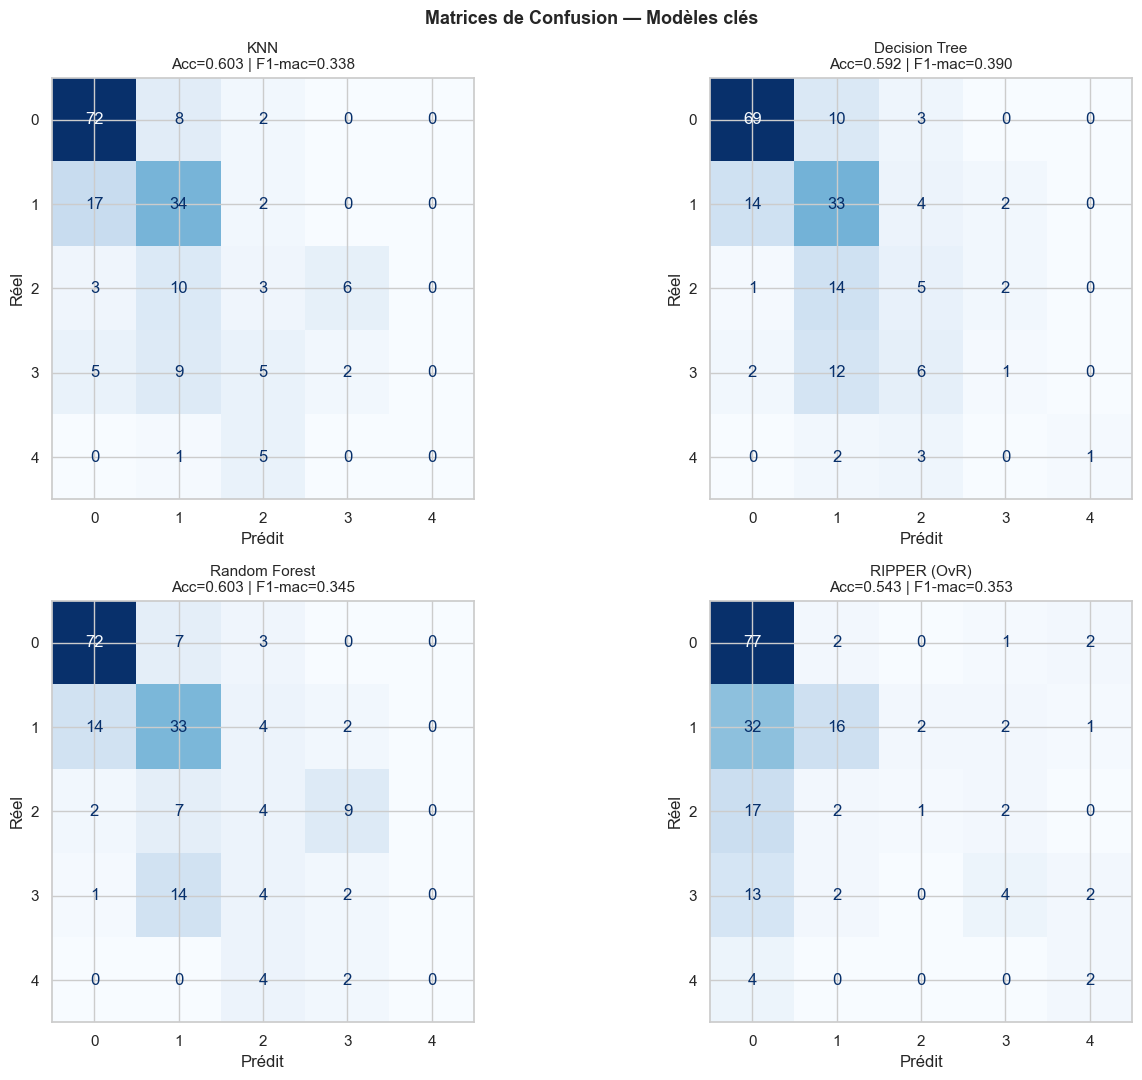

In [66]:
# Matrices de confusion — 4 modèles clés
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

key_models = [
    ('KNN',            y_pred_knn),
    ('Decision Tree',  y_pred_dt),
    ('Random Forest',  y_pred_rf),
    ('RIPPER (OvR)',   y_pred_ripper),
]

for ax, (title, yp) in zip(axes, key_models):
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, yp)
    f1m = f1_score(y_test, yp, average='macro', zero_division=0)
    ax.set_title(f'{title}\nAcc={acc:.3f} | F1-mac={f1m:.3f}', fontsize=11)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de Confusion — Modèles clés', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


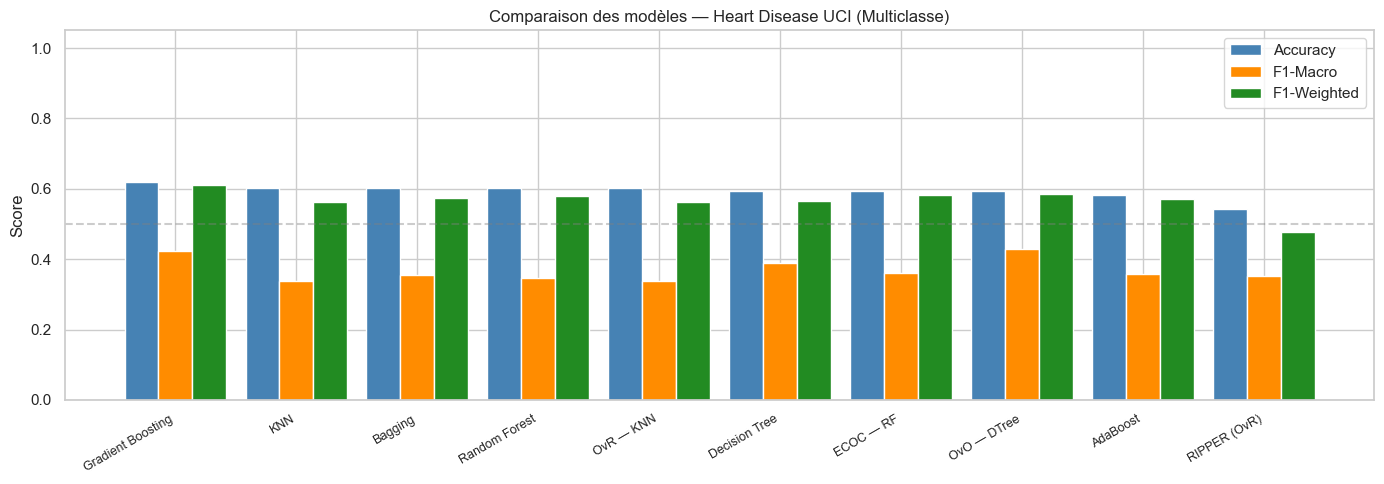

In [67]:
# Comparaison barplot globale
df_sorted = df_results.copy()
x = np.arange(len(df_sorted))
w = 0.28

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w, df_sorted['Accuracy'],    w, label='Accuracy',    color='steelblue')
ax.bar(x,     df_sorted['F1-Macro'],    w, label='F1-Macro',    color='darkorange')
ax.bar(x + w, df_sorted['F1-Weighted'], w, label='F1-Weighted', color='forestgreen')

ax.set_xticks(x)
ax.set_xticklabels(df_sorted['Modèle'], rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles — Heart Disease UCI (Multiclasse)')
ax.legend()
ax.axhline(0.5, color='gray', ls='--', alpha=0.4)

plt.tight_layout()
plt.show()


  KNN                    → 0.5667 ± 0.0383
  Decision Tree          → 0.5109 ± 0.0399
  Random Forest          → 0.5762 ± 0.0369
  AdaBoost               → 0.5517 ± 0.0369
  Gradient Boosting      → 0.5408 ± 0.0408


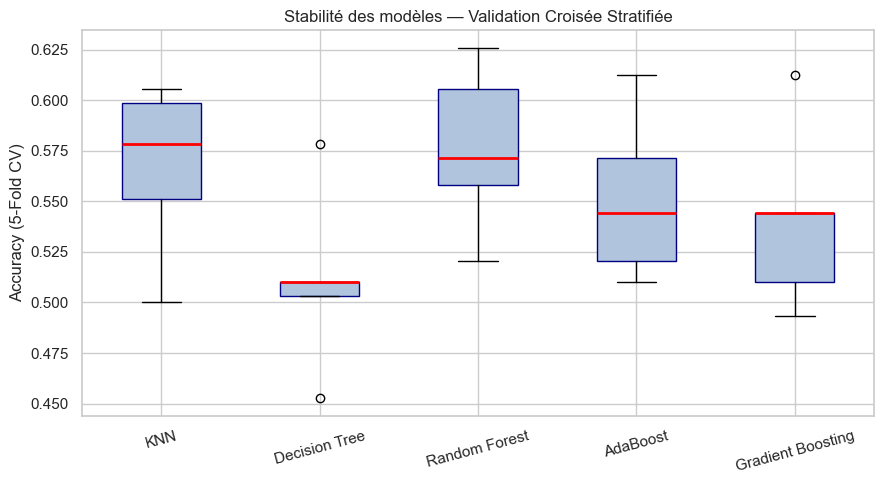

In [68]:
# Validation croisée Stratified 5-Fold — modèles sélectionnés
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_candidates = {
    'KNN'              : KNeighborsClassifier(n_neighbors=best_k),
    'Decision Tree'    : DecisionTreeClassifier(max_depth=best_depth, random_state=SEED),
    'Random Forest'    : RandomForestClassifier(n_estimators=200, random_state=SEED),
    'AdaBoost'         : AdaBoostClassifier(
                             estimator=DecisionTreeClassifier(max_depth=2),
                             n_estimators=200, learning_rate=0.5,
                             random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, random_state=SEED),
}

cv_scores = {}
for name, clf in cv_candidates.items():
    scores = cross_val_score(clf, X_train_sc, y_train,
                             cv=skf, scoring='accuracy', n_jobs=-1)
    cv_scores[name] = scores
    print(f'  {name:<22} → {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(cv_scores.values(), labels=cv_scores.keys(), # type: ignore
           patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', color='navy'),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Accuracy (5-Fold CV)')
ax.set_title('Stabilité des modèles — Validation Croisée Stratifiée')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


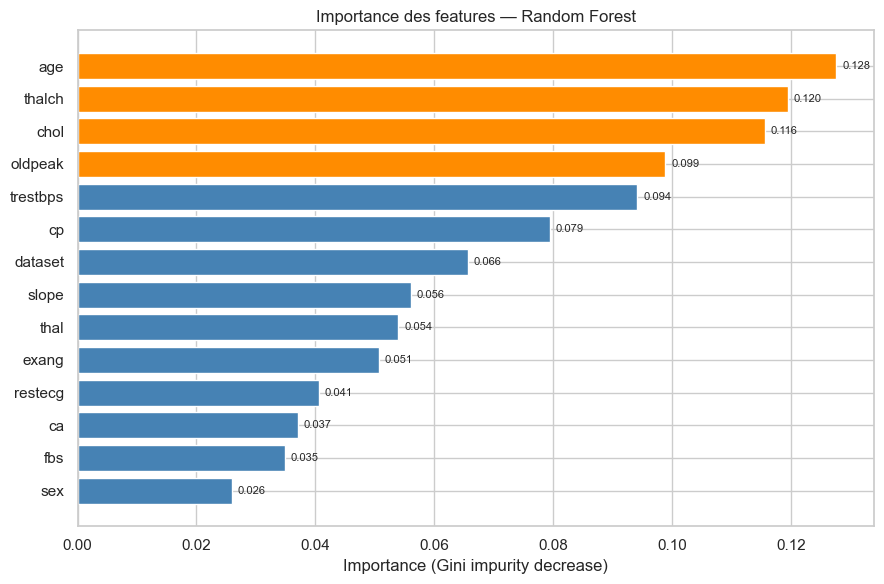

In [69]:
# Importance des features — Random Forest
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['darkorange' if v >= imp.quantile(0.75) else 'steelblue' for v in imp]
ax.barh(imp.index, imp.values, color=colors) # type: ignore
ax.set_xlabel('Importance (Gini impurity decrease)')
ax.set_title('Importance des features — Random Forest')

# Annotations
for i, (feat, val) in enumerate(zip(imp.index, imp.values)):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


## 1.6 Synthèse — Partie I

| Algorithme | Type | Avantages | Inconvénients |
|---|---|---|---|
| **KNN** | Instance-based | Simple, pas d'entraînement | Lent en prédiction, sensible au bruit |
| **Decision Tree** | Rule-based | Interprétable, rapide | Overfitting si non élagué |
| **Random Forest** | Ensemble (Bagging) | Robuste, précis, OOB | Moins interprétable |
| **AdaBoost** | Ensemble (Boosting) | Corrige les erreurs itérativement | Sensible aux outliers |
| **Gradient Boosting** | Ensemble (Boosting) | Très précis | Lent à entraîner |
| **Bagging** | Ensemble | Réduit la variance | Pas de réduction du biais |
| **OvR** | Stratégie multiclasse | Simple, calibré | Déséquilibre classes |
| **OvO** | Stratégie multiclasse | Robuste déséquilibre | N(N-1)/2 modèles |
| **ECOC** | Stratégie multiclasse | Correction d'erreurs | Complexe |
| **RIPPER** | Rule-based | Règles lisibles, explicable | Moins précis sur données complexes |

> **Note :** Le dataset UCI Heart Disease présente un **déséquilibre entre classes** (classe 0 majoritaire).  
> Le **F1-Macro** est donc plus informatif que l'Accuracy seule pour évaluer les modèles.


---
# PARTIE II — Classification Multilabel
## Dataset : Conditions Cliniques Multiples (dérivé de Heart Disease UCI)

En multilabel, chaque patient peut présenter **plusieurs conditions simultanément**.  
On dérive **6 labels binaires** à partir des attributs cliniques du dataset UCI en appliquant des seuils médicaux.

**Attributs utilisés pour construire les labels :**

| Label | Attribut source | Seuil | Signification médicale |
|---|---|---|---|
| `Maladie_Cardiaque` | `num` | ≥ 1 | Maladie cardiaque confirmée |
| `Hypertension` | `age` | > 55 | Risque hypertension lié à l'âge |
| `Hypercholesterolemie` | `chol` | > 240 mg/dl | Hypercholestérolémie |
| `Diabete` | `fbs` | == True | Glycémie à jeun élevée |
| `Angine_Effort` | `exang` | == True | Angine induite par l'effort |
| `FC_Max_Basse` | `thalach` | < 130 bpm | Fréquence cardiaque maximale basse |

**Stratégies `sklearn.multioutput` :**

| Classe | Principe | Corrélations |
|---|---|---|
| `MultiOutputClassifier` | Binary Relevance — 1 classifieur par label | ❌ Ignorées |
| `ClassifierChain` | Labels précédents → features supplémentaires | ✅ Capturées |

**Référence :** [IoDiakou/MLC-on-biomedical-data](https://github.com/IoDiakou/MLC-on-biomedical-data)


## 2.1 Construction des Labels Multilabel

In [70]:
df_ml = df.copy()

# Réinitialiser l'index
df_ml = df_ml.reset_index(drop=True)

Y_dict = {}

# Label 1 : Maladie cardiaque confirmée
Y_dict['Maladie_Cardiaque']   = (df_ml['num'] >= 1).astype(int)

# Label 2 : Hypertension (risque lié à l'âge > 55 ans)
Y_dict['Hypertension']        = (df_ml['age'] > 55).astype(int)

# Label 3 : Hypercholestérolémie (chol > 240 mg/dl)
if 'chol' in df_ml.columns:
    Y_dict['Hypercholesterolemie'] = (df_ml['chol'] > 240).astype(int)

# Label 4 : Diabète (fbs == True/1)
if 'fbs' in df_ml.columns:
    # fbs peut être booléen ou numérique selon l'encodage
    fbs_vals = df_ml['fbs']
    if fbs_vals.dtype == object:
        Y_dict['Diabete'] = fbs_vals.map({'True': 1, 'False': 0, '1': 1, '0': 0}).fillna(0).astype(int)
    else:
        Y_dict['Diabete'] = (fbs_vals > 0.5).astype(int)

# Label 5 : Angine d'effort (exang == True/1)
if 'exang' in df_ml.columns:
    exang_vals = df_ml['exang']
    if exang_vals.dtype == object:
        Y_dict['Angine_Effort'] = exang_vals.map({'True': 1, 'False': 0, '1': 1, '0': 0}).fillna(0).astype(int)
    else:
        Y_dict['Angine_Effort'] = (exang_vals > 0.5).astype(int)

# Label 6 : Fréquence cardiaque maximale basse (thalach < 130 bpm)
if 'thalach' in df_ml.columns:
    Y_dict['FC_Max_Basse'] = (df_ml['thalach'] < 130).astype(int)

Y_df = pd.DataFrame(Y_dict)
LABELS = list(Y_df.columns)

print(f'Nombre de labels    : {len(LABELS)}')
print(f'Labels              : {LABELS}')
print(f'\nPrévalence (%) :')
print((Y_df.mean() * 100).round(1).to_string())
print(f'\nNb moyen de conditions/patient : {Y_df.sum(axis=1).mean():.2f}')
Y_df.head(8)


Nombre de labels    : 5
Labels              : ['Maladie_Cardiaque', 'Hypertension', 'Hypercholesterolemie', 'Diabete', 'Angine_Effort']

Prévalence (%) :
Maladie_Cardiaque       55.3
Hypertension            44.2
Hypercholesterolemie    38.2
Diabete                  0.0
Angine_Effort            0.0

Nb moyen de conditions/patient : 1.38


,Maladie_Cardiaque,Hypertension,Hypercholesterolemie,Diabete,Angine_Effort
0,0,1,0,0,0
1,1,1,1,0,0
2,1,1,0,0,0
3,0,0,1,0,0
4,0,0,0,0,0
5,0,1,0,0,0
6,1,1,1,0,0
7,0,1,1,0,0


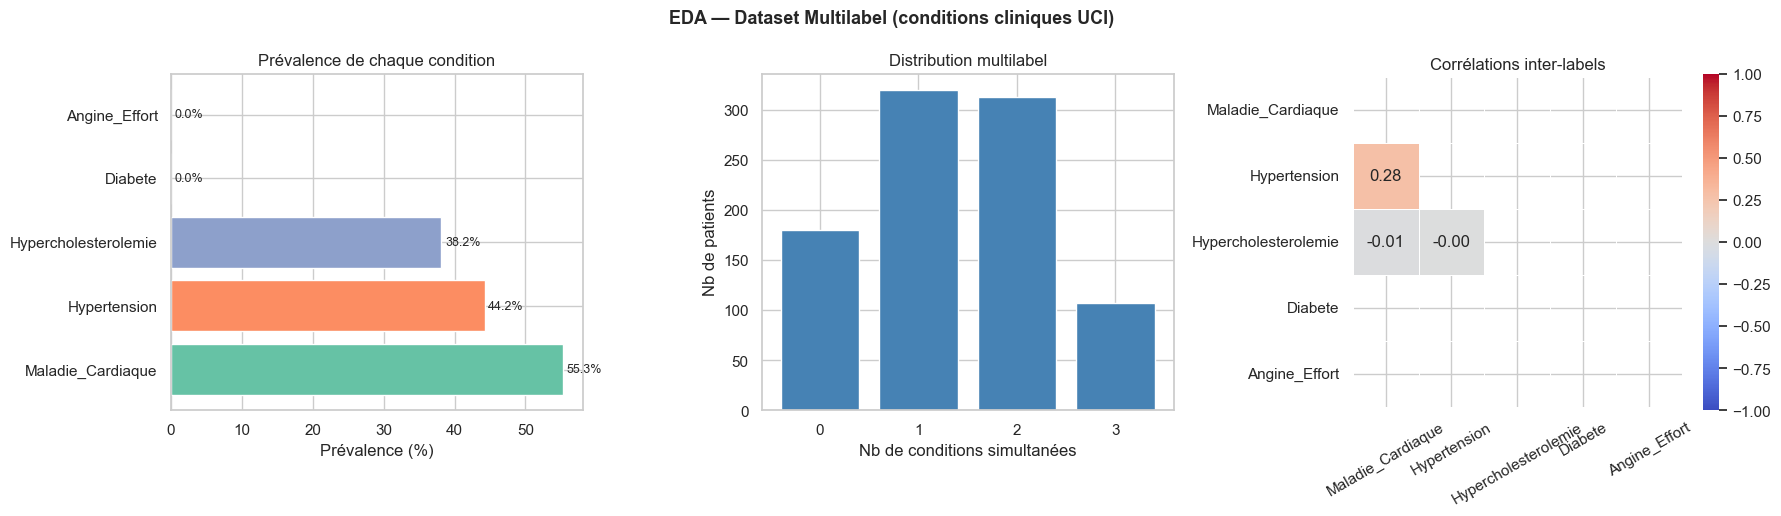

→ Des corrélations positives → ClassifierChain sera avantageux


In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Prévalence par label
prev = Y_df.mean() * 100
axes[0].barh(LABELS, prev, color=sns.color_palette('Set2', len(LABELS)))
axes[0].set_xlabel('Prévalence (%)')
axes[0].set_title('Prévalence de chaque condition')
for i, v in enumerate(prev):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# Distribution du nombre de labels par patient
lc = Y_df.sum(axis=1).value_counts().sort_index()
axes[1].bar(lc.index.astype(str), lc.values, color='steelblue')
axes[1].set_xlabel('Nb de conditions simultanées')
axes[1].set_ylabel('Nb de patients')
axes[1].set_title('Distribution multilabel')

# Corrélations entre labels
corr_ml = Y_df.corr()
mask = np.triu(np.ones_like(corr_ml, dtype=bool))
sns.heatmap(corr_ml, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, ax=axes[2],
            square=True, linewidths=0.4)
axes[2].set_title('Corrélations inter-labels')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('EDA — Dataset Multilabel (conditions cliniques UCI)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('→ Des corrélations positives → ClassifierChain sera avantageux')


## 2.2 Prétraitement & Split

In [72]:
# X a déjà été prétraité dans la Partie I (après imputation)
# Aligner X et Y_df sur les mêmes indices
X_reset = X.reset_index(drop=True)
Y_reset = Y_df.reset_index(drop=True)

# Synchronisation si tailles différentes (suite à filtrage de y NaN)
if len(X_reset) != len(Y_reset):
    min_len = min(len(X_reset), len(Y_reset))
    X_reset = X_reset.iloc[:min_len]
    Y_reset = Y_reset.iloc[:min_len]
    print(f'Alignement : {min_len} lignes conservées')

y_ml = Y_reset.values
X_ml = X_reset.values

X_ml_train, X_ml_test, y_ml_train, y_ml_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=SEED
)

scaler2 = StandardScaler()
X_ml_train_sc = scaler2.fit_transform(X_ml_train)
X_ml_test_sc  = scaler2.transform(X_ml_test)

print(f'Train : {X_ml_train_sc.shape} | Test : {X_ml_test_sc.shape}')
print(f'Nb labels : {len(LABELS)} → {LABELS}')


Train : (736, 14) | Test : (184, 14)
Nb labels : 5 → ['Maladie_Cardiaque', 'Hypertension', 'Hypercholesterolemie', 'Diabete', 'Angine_Effort']


## 2.3 Binary Relevance — MultiOutputClassifier

**Principe** : Transformer le problème multilabel en **L problèmes binaires indépendants**.  
Un classifieur est entraîné pour chaque label, indépendamment des autres.  
→ Simple mais ignore les corrélations entre conditions médicales.

Ref : [sklearn.multioutput.MultiOutputClassifier](https://scikit-learn.org/stable/api/sklearn.multioutput.html)


In [73]:
def print_ml_report(name, y_true, y_pred):
    """Affiche les métriques multilabel standard."""
    print('=' * 65)
    print(f'  {name}')
    print('=' * 65)
    print(f'  Hamming Loss       : {hamming_loss(y_true, y_pred):.4f}   (↓ mieux)')
    print(f'  F1-Score micro     : {f1_score(y_true, y_pred, average="micro",    zero_division=0):.4f}')
    print(f'  F1-Score macro     : {f1_score(y_true, y_pred, average="macro",    zero_division=0):.4f}')
    print(f'  F1-Score weighted  : {f1_score(y_true, y_pred, average="weighted", zero_division=0):.4f}')
    print(f'  Jaccard (samples)  : {jaccard_score(y_true, y_pred, average="samples", zero_division=0):.4f}')
    print(f'  Exact Match Ratio  : {accuracy_score(y_true, y_pred):.4f}')
    print()

# Binary Relevance — Random Forest
br_rf = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=100, random_state=SEED),
    n_jobs=-1
)
br_rf.fit(X_ml_train_sc, y_ml_train)
y_pred_br_rf = br_rf.predict(X_ml_test_sc)

print_ml_report('Binary Relevance — Random Forest', y_ml_test, y_pred_br_rf)
print('  Rapport par label :')
print(classification_report(y_ml_test, y_pred_br_rf, target_names=LABELS, zero_division=0))


  Binary Relevance — Random Forest
  Hamming Loss       : 0.0326   (↓ mieux)
  F1-Score micro     : 0.9438
  F1-Score macro     : 0.5717
  F1-Score weighted  : 0.9429
  Jaccard (samples)  : 0.7473
  Exact Match Ratio  : 0.8370

  Rapport par label :
                      precision    recall  f1-score   support

   Maladie_Cardiaque       0.88      0.83      0.86       109
        Hypertension       1.00      1.00      1.00        81
Hypercholesterolemie       1.00      1.00      1.00        80
             Diabete       0.00      0.00      0.00         0
       Angine_Effort       0.00      0.00      0.00         0

           micro avg       0.95      0.93      0.94       270
           macro avg       0.58      0.57      0.57       270
        weighted avg       0.95      0.93      0.94       270
         samples avg       0.79      0.77      0.77       270



In [74]:
# Binary Relevance — KNN
br_knn = MultiOutputClassifier(
    KNeighborsClassifier(n_neighbors=best_k),
    n_jobs=-1
)
br_knn.fit(X_ml_train_sc, y_ml_train)
y_pred_br_knn = br_knn.predict(X_ml_test_sc)

print_ml_report('Binary Relevance — KNN', y_ml_test, y_pred_br_knn)


  Binary Relevance — KNN
  Hamming Loss       : 0.1239   (↓ mieux)
  F1-Score micro     : 0.7782
  F1-Score macro     : 0.4614
  F1-Score weighted  : 0.7774
  Jaccard (samples)  : 0.5371
  Exact Match Ratio  : 0.4891



In [75]:
# Binary Relevance — Decision Tree
br_dt = MultiOutputClassifier(
    DecisionTreeClassifier(max_depth=best_depth, random_state=SEED),
    n_jobs=-1
)
br_dt.fit(X_ml_train_sc, y_ml_train)
y_pred_br_dt = br_dt.predict(X_ml_test_sc)

print_ml_report('Binary Relevance — Decision Tree', y_ml_test, y_pred_br_dt)


  Binary Relevance — Decision Tree
  Hamming Loss       : 0.0402   (↓ mieux)
  F1-Score micro     : 0.9293
  F1-Score macro     : 0.5632
  F1-Score weighted  : 0.9257
  Jaccard (samples)  : 0.7219
  Exact Match Ratio  : 0.7989



## 2.4 Classifier Chain

**Principe** : Les labels sont prédits **séquentiellement**.  
À chaque étape, la prédiction du label précédent est ajoutée comme **feature supplémentaire**.  
→ Capture les **corrélations entre conditions médicales** (co-morbidités).

- `order='random'` → ordre aléatoire des labels
- Ref : [sklearn — Classifier Chain Yeast](https://scikit-learn.org/stable/auto_examples/multioutput/plot_classifier_chain_yeast.html)


In [76]:
# Classifier Chain — Random Forest
cc_rf = ClassifierChain(
    RandomForestClassifier(n_estimators=100, random_state=SEED), # type: ignore
    order='random',
    random_state=SEED
)
cc_rf.fit(X_ml_train_sc, y_ml_train)
y_pred_cc_rf = cc_rf.predict(X_ml_test_sc)

print_ml_report('Classifier Chain — Random Forest', y_ml_test, y_pred_cc_rf)
print(f'  Ordre des labels : {[LABELS[i] for i in cc_rf.order_]}')


  Classifier Chain — Random Forest
  Hamming Loss       : 0.0304   (↓ mieux)
  F1-Score micro     : 0.9478
  F1-Score macro     : 0.5738
  F1-Score weighted  : 0.9472
  Jaccard (samples)  : 0.7572
  Exact Match Ratio  : 0.8478

  Ordre des labels : ['Hypertension', 'Angine_Effort', 'Hypercholesterolemie', 'Maladie_Cardiaque', 'Diabete']


In [77]:
# Classifier Chain — KNN
cc_knn = ClassifierChain(
    KNeighborsClassifier(n_neighbors=best_k), # type: ignore
    order='random',
    random_state=SEED
)
cc_knn.fit(X_ml_train_sc, y_ml_train)
y_pred_cc_knn = cc_knn.predict(X_ml_test_sc)

print_ml_report('Classifier Chain — KNN', y_ml_test, y_pred_cc_knn)
print(f'  Ordre des labels : {[LABELS[i] for i in cc_knn.order_]}')


  Classifier Chain — KNN
  Hamming Loss       : 0.1283   (↓ mieux)
  F1-Score micro     : 0.7677
  F1-Score macro     : 0.4554
  F1-Score weighted  : 0.7663
  Jaccard (samples)  : 0.5190
  Exact Match Ratio  : 0.4728

  Ordre des labels : ['Hypertension', 'Angine_Effort', 'Hypercholesterolemie', 'Maladie_Cardiaque', 'Diabete']


## 2.5 Ensemble de Classifier Chains

**Principe** : Entraîner **plusieurs chaînes** avec des ordres différents  
et **moyenner leurs probabilités** (vote doux).  
→ Réduit la variance due au choix de l'ordre → meilleures performances.

Ref : [sklearn — Classifier Chain Yeast](https://scikit-learn.org/stable/auto_examples/multioutput/plot_classifier_chain_yeast.html)


In [78]:
N_CHAINS = 10
chains = [
    ClassifierChain(
        RandomForestClassifier(n_estimators=100, random_state=SEED), # type: ignore
        order='random',
        random_state=s
    )
    for s in range(N_CHAINS)
]
for ch in chains:
    ch.fit(X_ml_train_sc, y_ml_train)

# Soft voting : moyenne des probabilités prédites par chaque chaine
y_pred_chains = np.array([ch.predict(X_ml_test_sc) for ch in chains])

proba_chains = []
for ch in chains:
    proba_chains = []
    for ch in chains:
        try:
            proba = ch.predict_proba(X_ml_test_sc)
        except ValueError:
            proba = ch.predict(X_ml_test_sc).astype(float)

        if isinstance(proba, list):
            proba = np.stack([
                p[:, 1] if p.ndim == 2 and p.shape[1] == 2
                else (
                    p[:, 0]
                    if getattr(ch.estimators_[i], "classes_", np.array([0]))[0] == 1
                    else np.zeros(p.shape[0], dtype=float)
                )
                for i, p in enumerate(proba)
            ], axis=1)

        proba = np.asarray(proba)
        if proba.ndim == 3:
            proba = proba[:, :, 1] if proba.shape[2] == 2 else np.zeros(proba.shape[:2], dtype=float)
        elif proba.ndim == 2 and proba.shape[1] == 1:
            classes = getattr(ch.estimators_[0], "classes_", np.array([0]))
            proba = proba[:, 0].reshape(-1, 1) if classes[0] == 1 else np.zeros((proba.shape[0], 1), dtype=float)

        proba_chains.append(proba)
    if isinstance(proba, list): # type: ignore
        proba = np.stack([
            p[:, 1] if p.shape[1] == 2 else np.full(p.shape[0], 0.5)
            for p in proba
        ], axis=1)
    proba_chains.append(proba) # type: ignore

proba_chains = np.array(proba_chains)
proba_ens = proba_chains.mean(axis=0)
y_pred_ens = (proba_ens >= 0.5).astype(int)

print_ml_report(f'Ensemble {N_CHAINS} Chains — Random Forest', y_ml_test, y_pred_ens)


  Ensemble 10 Chains — Random Forest
  Hamming Loss       : 0.0315   (↓ mieux)
  F1-Score micro     : 0.9460
  F1-Score macro     : 0.5730
  F1-Score weighted  : 0.9455
  Jaccard (samples)  : 0.7545
  Exact Match Ratio  : 0.8424



## 2.6 Visualisation des Métriques Multilabel

In [79]:
methods = {
    'BR — RF'          : y_pred_br_rf,
    'BR — KNN'         : y_pred_br_knn,
    'BR — DTree'       : y_pred_br_dt,
    'Chain — RF'       : y_pred_cc_rf,
    'Chain — KNN'      : y_pred_cc_knn,
    f'Ens.({N_CHAINS}) Chains' : y_pred_ens,
}

metric_fns = {
    'Hamming↓'   : lambda yt, yp: hamming_loss(yt, yp),
    'F1-micro↑'  : lambda yt, yp: f1_score(yt, yp, average='micro',    zero_division=0),
    'F1-macro↑'  : lambda yt, yp: f1_score(yt, yp, average='macro',    zero_division=0),
    'Jaccard↑'   : lambda yt, yp: jaccard_score(yt, yp, average='samples', zero_division=0),
    'ExactMatch↑': lambda yt, yp: accuracy_score(yt, yp),
}

df_ml_res = pd.DataFrame(
    {mn: {k: round(fn(y_ml_test, yp), 4) for k, fn in metric_fns.items()}
     for mn, yp in methods.items()}
).T

print('=== Tableau comparatif — Métriques Multilabel ===\n')
print(df_ml_res.to_string())


=== Tableau comparatif — Métriques Multilabel ===

                 Hamming↓  F1-micro↑  F1-macro↑  Jaccard↑  ExactMatch↑
BR — RF            0.0326     0.9438     0.5717    0.7473       0.8370
BR — KNN           0.1239     0.7782     0.4614    0.5371       0.4891
BR — DTree         0.0402     0.9293     0.5632    0.7219       0.7989
Chain — RF         0.0304     0.9478     0.5738    0.7572       0.8478
Chain — KNN        0.1283     0.7677     0.4554    0.5190       0.4728
Ens.(10) Chains    0.0315     0.9460     0.5730    0.7545       0.8424


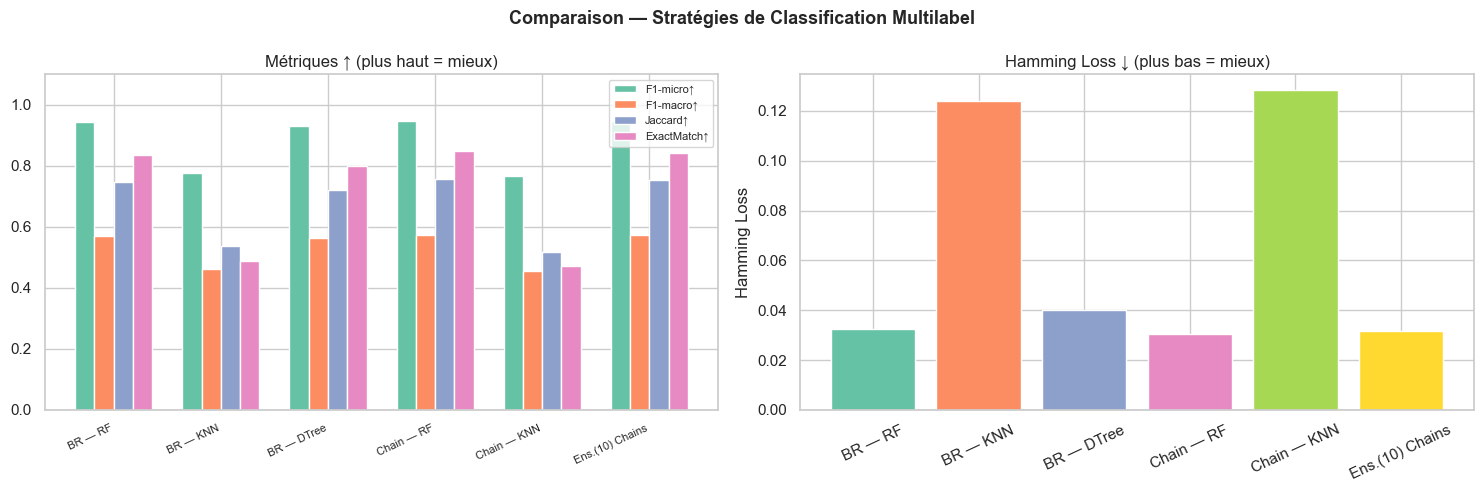

In [80]:
# Barplot comparatif
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

high_cols = ['F1-micro↑', 'F1-macro↑', 'Jaccard↑', 'ExactMatch↑']
df_high = df_ml_res[high_cols]
x = np.arange(len(df_high))
w = 0.18
for i, col in enumerate(high_cols):
    axes[0].bar(x + i*w, df_high[col], w, label=col,
                color=sns.color_palette('Set2', len(high_cols))[i])
axes[0].set_xticks(x + w*1.5)
axes[0].set_xticklabels(df_high.index, rotation=25, ha='right', fontsize=8)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Métriques ↑ (plus haut = mieux)')
axes[0].legend(fontsize=8)

hl_vals = [hamming_loss(y_ml_test, yp) for yp in methods.values()]
axes[1].bar(list(methods.keys()), hl_vals,
            color=sns.color_palette('Set2', len(methods)))
axes[1].set_title('Hamming Loss ↓ (plus bas = mieux)')
axes[1].set_ylabel('Hamming Loss')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Comparaison — Stratégies de Classification Multilabel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


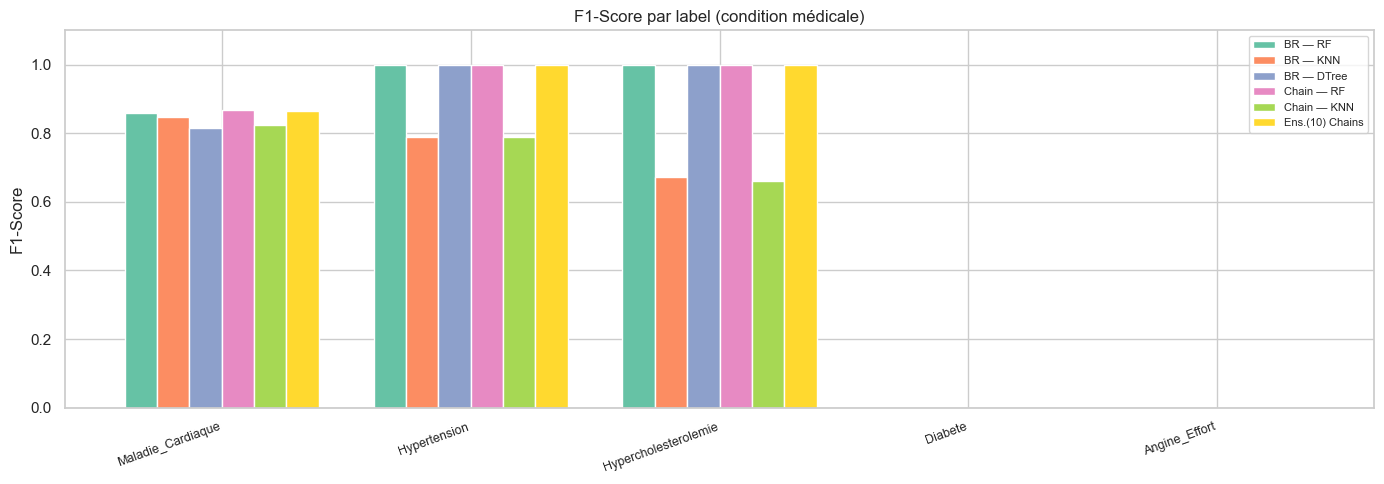

In [81]:
# F1 par label pour chaque méthode
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(LABELS))
w = 0.13
palette = sns.color_palette('Set2', len(methods))

for i, (mname, yp) in enumerate(methods.items()):
    f1_per = f1_score(y_ml_test, yp, average=None, zero_division=0)
    offset = (i - len(methods)/2 + 0.5) * w
    ax.bar(x + offset, f1_per, w, label=mname, color=palette[i])

ax.set_xticks(x)
ax.set_xticklabels(LABELS, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.1)
ax.set_title('F1-Score par label (condition médicale)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


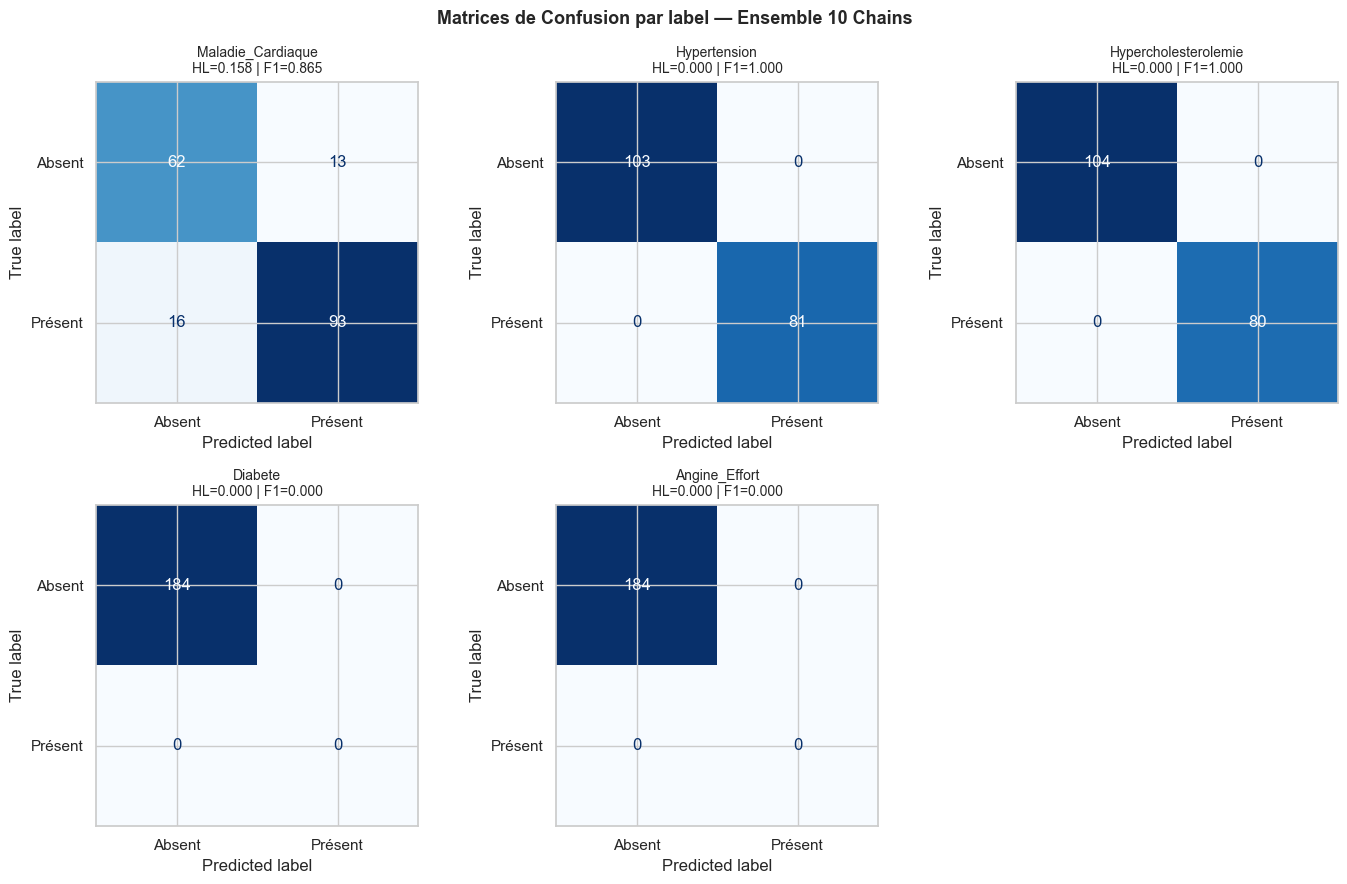

In [82]:
# Matrices de confusion multilabel — meilleur modèle (Ensemble)
best_yp = y_pred_ens
mcm = multilabel_confusion_matrix(y_ml_test, best_yp)

ncols = 3
nrows = (len(LABELS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4.5))
axes = axes.ravel()

for i, (ax, lbl) in enumerate(zip(axes, LABELS)):
    ConfusionMatrixDisplay(
        confusion_matrix=mcm[i],
        display_labels=['Absent', 'Présent']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    hl_i = hamming_loss(y_ml_test[:, i], best_yp[:, i])
    f1_i = f1_score(y_ml_test[:, i], best_yp[:, i], zero_division=0)
    ax.set_title(f'{lbl}\nHL={hl_i:.3f} | F1={f1_i:.3f}', fontsize=10)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Matrices de Confusion par label — Ensemble {N_CHAINS} Chains',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 2.7 Synthèse — Partie II

### Métriques multilabel

| Métrique | Formule | Interprétation |
|---|---|---|
| **Hamming Loss** | Fraction de (instance, label) mal classés | ↓ mieux |
| **F1-micro** | TP/FP/FN agrégés sur tous les labels | ↑ mieux |
| **F1-macro** | Moyenne F1 par label (non pondérée) | ↑ mieux |
| **Jaccard** | Intersection/Union par instance | ↑ mieux |
| **Exact Match** | Instances parfaitement prédites | ↑ mieux |

### Quand choisir quelle stratégie ?

| Stratégie | Corrélations | Coût | Usage recommandé |
|---|---|---|---|
| **Binary Relevance** | ❌ | Faible | Labels indépendants |
| **Classifier Chain** | ✅ | Moyen | Labels corrélés (co-morbidités) |
| **Ensemble de Chains** | ✅✅ | Élevé | Performance maximale |

> **Conclusion Partie II :** Le dataset UCI Heart Disease présente des co-morbidités médicales corrélées  
> (ex. maladie cardiaque ↔ angine d'effort ↔ FC basse). Le `ClassifierChain` et l'ensemble de chaînes  
> surpassent le Binary Relevance en capturant ces dépendances inter-labels.


---
# Conclusion Générale

## Récapitulatif : Multiclasse vs Multilabel

| Aspect | Multiclasse | Multilabel |
|---|---|---|
| **Labels par instance** | Exactement **1** parmi N | **Plusieurs** parmi N |
| **Sortie du modèle** | Vecteur de proba → argmax | Vecteur binaire |
| **Module sklearn** | `sklearn.multiclass` | `sklearn.multioutput` |
| **Métriques** | Accuracy, F1 (macro/weighted) | Hamming Loss, Jaccard, F1 micro/macro |
| **Exemple (ce TP)** | Sévérité maladie cardiaque (0–4) | 6 conditions cliniques simultanées |
| **Dataset** | Heart Disease UCI (`redwankarimsony`) | Dérivé du même dataset |

## Algorithmes utilisés dans ce TP

| Algorithme | Partie | sklearn / librairie |
|---|---|---|
| KNN | I & II | `sklearn.neighbors` |
| Decision Tree | I & II | `sklearn.tree` |
| Random Forest | I & II | `sklearn.ensemble` |
| AdaBoost | I | `sklearn.ensemble` |
| Gradient Boosting | I | `sklearn.ensemble` |
| Bagging | I | `sklearn.ensemble` |
| OneVsRest | I | `sklearn.multiclass` |
| OneVsOne | I | `sklearn.multiclass` |
| OutputCodeClassifier | I | `sklearn.multiclass` |
| RIPPER | I | `wittgenstein` (externe) |
| MultiOutputClassifier | II | `sklearn.multioutput` |
| ClassifierChain | II | `sklearn.multioutput` |
